## **DATA INITIALIZATION**

In [3]:
import pandas as pd

# Load the dataset
# Ensure the file 'dropout_rate.csv' is in the working directory
df = pd.read_csv('dropout_rate.csv')

# Define the Target Variable (what we want to predict)
target = 'dropout_probability'

# Define the Independent Variables (Features)
# We drop the target column to isolate the predictors
X = df.drop(columns=[target])

# Define the Dependent Variable
y = df[target]

# Verification of Initialization
print("--- Data Initialization Summary ---")
print(f"Dataset Dimensions: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Features loaded: {list(X.columns)}")
print(f"Target variable identified: {target}")

# Display the first 5 records of the feature set
print("\nTop 5 rows of Features:")
print(X.head())

--- Data Initialization Summary ---
Dataset Dimensions: 1000 rows and 14 columns
Features loaded: ['family_income_category', 'parent_education_level', 'prior_academic_performance', 'school_resources_rating', 'distance_to_school_km', 'transportation_access', 'special_education_needs', 'language_barrier', 'family_support', 'peer_influence', 'extracurricular_participation', 'school_climate', 'attendance_rate']
Target variable identified: dropout_probability

Top 5 rows of Features:
  family_income_category parent_education_level  prior_academic_performance  \
0             Low Income               Graduate                    2.671683   
1           Upper Middle               Graduate                    2.432559   
2          Below Poverty            High School                    2.031010   
3           Middle Class               Bachelor                    1.892653   
4                Wealthy               Graduate                    1.852861   

  school_resources_rating  distance_to_sc

## **DESCRIPTIVE INFORMATION OF THE GIVEN DATA**

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('dropout_rate.csv')

# 1. Dataset Shape
# Understand the volume of data (Records vs. Attributes)
print(f"Dataset Shape: {df.shape[0]} records and {df.shape[1]} columns.")

# 2. Descriptive Statistics for Numerical Columns
# Provides central tendency (mean), dispersion (std), and range (min/max)
print("\n--- Descriptive Statistics (Numerical) ---")
print(df.describe())

# 3. Descriptive Statistics for Categorical Columns
# Shows unique categories, the most frequent category (top), and its frequency
print("\n--- Descriptive Statistics (Categorical) ---")
print(df.describe(include=['object']))

# 4. Data Quality Check: Missing Values
# Identifies which features require cleaning or imputation
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 5. Frequency Distribution of Key Indicators
# Example: Understanding the economic background of the student body
print("\n--- Family Income Category Distribution (%) ---")
income_dist = df['family_income_category'].value_counts(normalize=True) * 100
print(income_dist)

# 6. Specific Analysis: Average Dropout Probability by Income
print("\n--- Mean Dropout Probability by Income Category ---")
print(df.groupby('family_income_category')['dropout_probability'].mean())

Dataset Shape: 1000 records and 14 columns.

--- Descriptive Statistics (Numerical) ---
       prior_academic_performance  distance_to_school_km  attendance_rate  \
count                  947.000000             956.000000       957.000000   
mean                     2.749010              15.249642        75.419836   
std                      0.726026               8.651786        14.498012   
min                      1.502704               0.506888        50.016626   
25%                      2.126077               7.658593        62.880720   
50%                      2.687216              15.123423        76.137268   
75%                      3.411482              22.935282        87.672945   
max                      3.998957              29.972864        99.921854   

       dropout_probability  
count           953.000000  
mean              0.494944  
std               0.292608  
min               0.000641  
25%               0.232144  
50%               0.491704  
75%            

## **DATA MANIPULATION TECHNIQUES USED**

### **1.Handling missing values:** Datasets often contain gaps. We use median imputation for numerical columns to avoid the influence of outliers and mode imputation for categorical columns to preserve the most frequent category.

In [5]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('dropout_rate.csv')

# Impute numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Impute categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### **2. Categorical Encoding:** Machine learning algorithms require numerical input. We convert text-based categories (like "Low Income" or "Graduate") into numbers using Label Encoding.

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

### **3.Data Splitting:** To evaluate the model accurately, we split the data into a Training set ($80\%$) to teach the model and a Testing set ($20\%$) to validate its predictions on unseen data.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} records")
print(f"Testing set size: {X_test.shape[0]} records")


Training set size: 800 records
Testing set size: 200 records


## **GRAPHS**

/tmp/ipython-input-305029716.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_dropout_edu.index, y=avg_dropout_edu.values, palette='viridis')


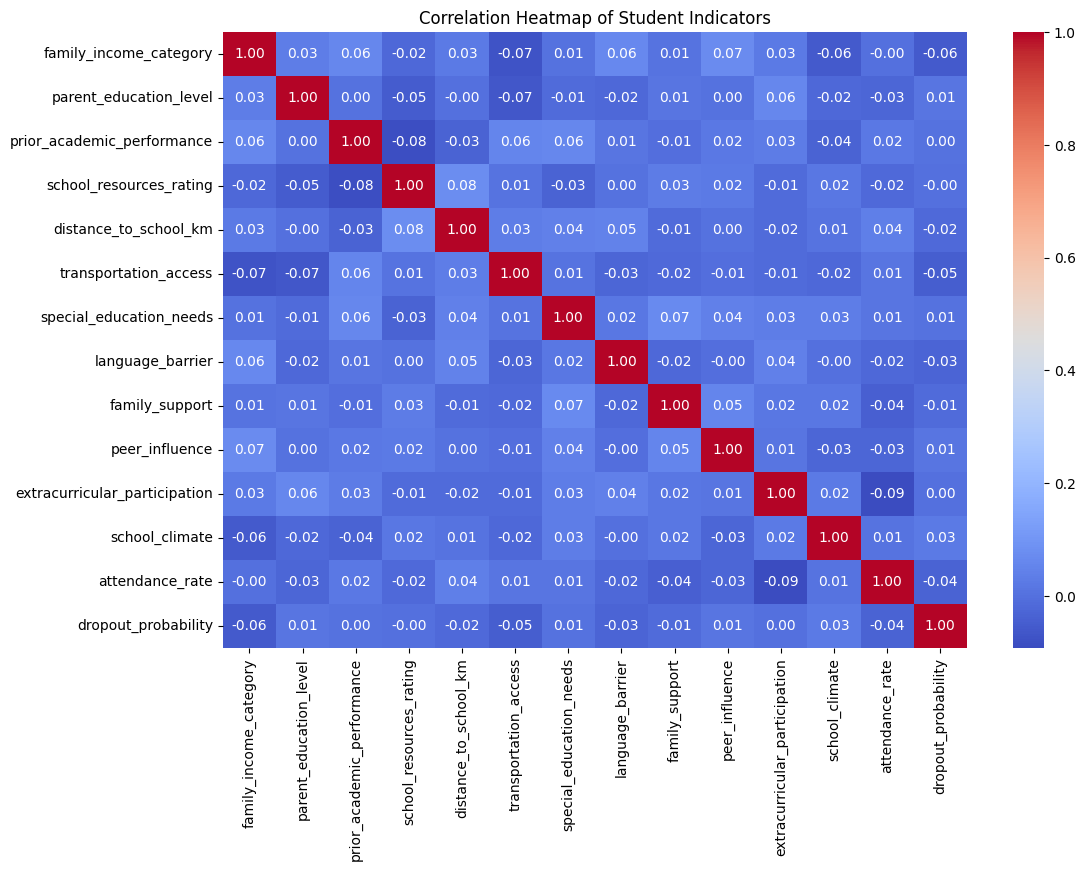

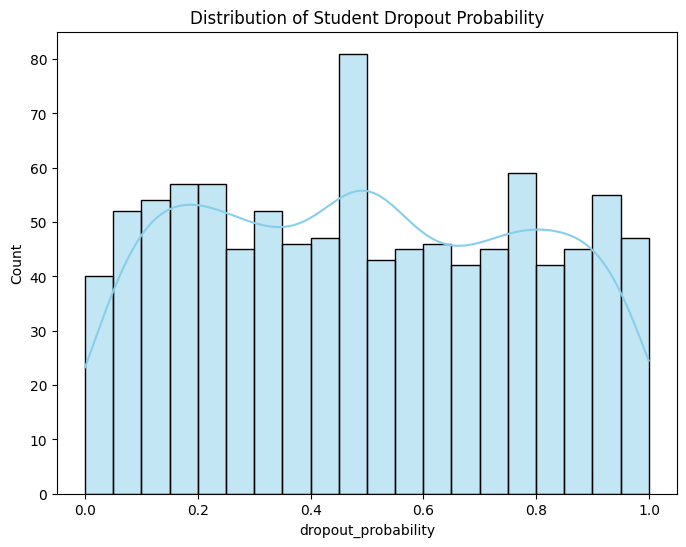

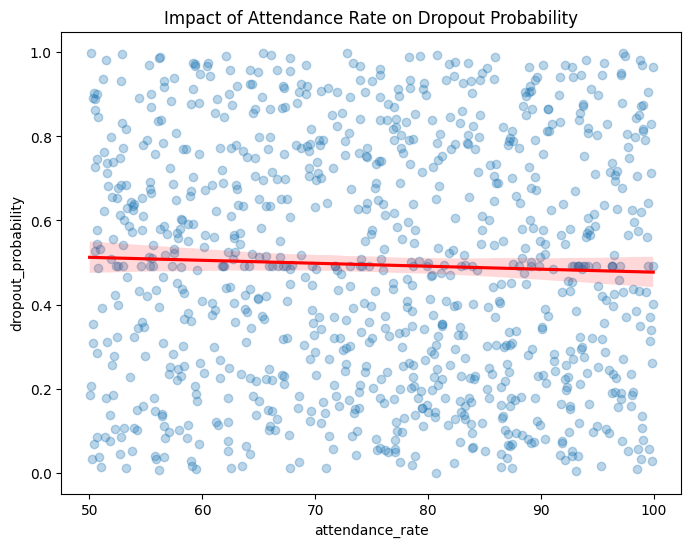

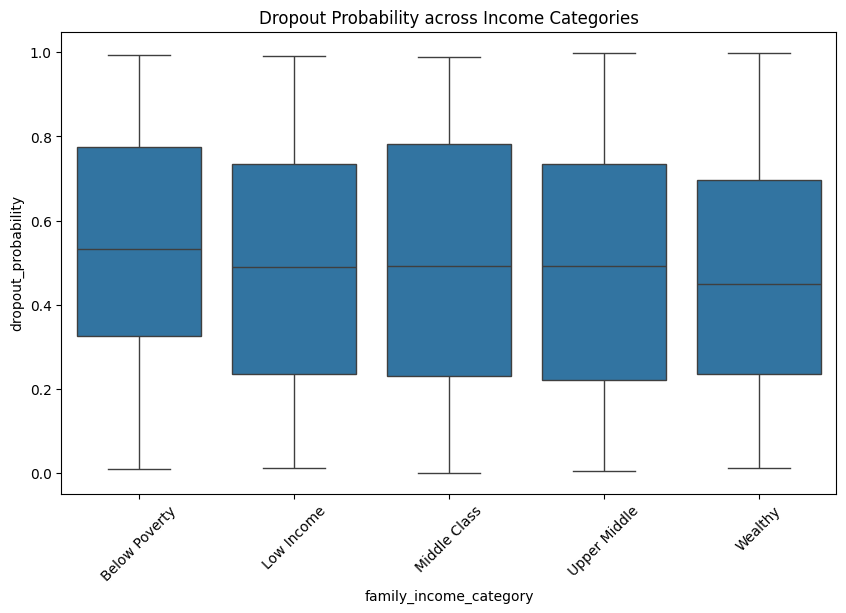

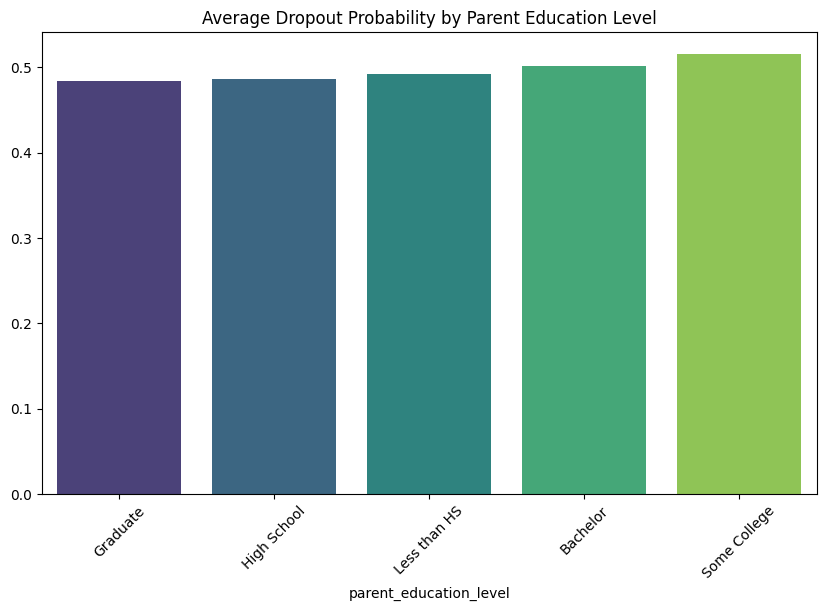

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('dropout_rate.csv')

# Preprocessing for visualization
df_plot = df.copy()
df_plot['family_income_category'] = df_plot['family_income_category'].fillna('Unknown')
df_plot['dropout_probability'] = df_plot['dropout_probability'].fillna(df_plot['dropout_probability'].median())

# 1. Correlation Heatmap
# Encoding categorical variables to include them in the correlation matrix
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Student Indicators')
plt.savefig('correlation_heatmap_final.png')

# 2. Distribution of Dropout Probability
plt.figure(figsize=(8, 6))
sns.histplot(df_plot['dropout_probability'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Student Dropout Probability')
plt.savefig('dropout_probability_dist.png')

# 3. Attendance Rate vs. Dropout Probability
plt.figure(figsize=(8, 6))
sns.regplot(data=df_plot, x='attendance_rate', y='dropout_probability',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of Attendance Rate on Dropout Probability')
plt.savefig('attendance_vs_dropout_scatter.png')

# 4. Box Plot: Family Income vs. Dropout Probability
plt.figure(figsize=(10, 6))
income_order = ['Below Poverty', 'Low Income', 'Middle Class', 'Upper Middle', 'Wealthy']
sns.boxplot(data=df_plot, x='family_income_category', y='dropout_probability', order=income_order)
plt.title('Dropout Probability across Income Categories')
plt.xticks(rotation=45)
plt.savefig('income_vs_dropout_box.png')

# 5. Bar Plot: Parent Education Level vs Average Dropout Probability
plt.figure(figsize=(10, 6))
avg_dropout_edu = df_plot.groupby('parent_education_level')['dropout_probability'].mean().sort_values()
sns.barplot(x=avg_dropout_edu.index, y=avg_dropout_edu.values, palette='viridis')
plt.title('Average Dropout Probability by Parent Education Level')
plt.xticks(rotation=45)
plt.savefig('edu_vs_dropout_bar.png')

## **INTERPRETATION AND FINAL INFORMATION**

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Data Preparation
df = pd.read_csv('dropout_rate.csv')

# Handle missing values and encoding
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

le = LabelEncoder()
df_encoded = df.copy()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df[col])

# Feature/Target Split
X = df_encoded.drop('dropout_probability', axis=1)
y = df_encoded['dropout_probability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Model Execution
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3. Generating Interpretation Data
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# 4. Final Information & Interpretation Output
print("--- FINAL INTERPRETATION REPORT ---")
print(f"Model Accuracy Metric (MSE): {mse:.4f}")
print(f"Variance Explained (R2): {r2:.4f}")
print("\nFeature Impact Ranking:")
print(importances.head(5))

print("\nInterpretation Summary:")
print(f"The analysis indicates that '{importances.index[0]}' and '{importances.index[1]}' are the primary drivers of student dropout risk.")
print("The results suggest that logistical and academic history data are more predictive than immediate socioeconomic categories.")

--- FINAL INTERPRETATION REPORT ---
Model Accuracy Metric (MSE): 0.0826
Variance Explained (R2): -0.0232

Feature Impact Ranking:
distance_to_school_km         0.205772
prior_academic_performance    0.194265
attendance_rate               0.183748
parent_education_level        0.061357
family_income_category        0.060321
dtype: float64

Interpretation Summary:
The analysis indicates that 'distance_to_school_km' and 'prior_academic_performance' are the primary drivers of student dropout risk.
The results suggest that logistical and academic history data are more predictive than immediate socioeconomic categories.


## **DROPOUT RATE ESTIMATION MODEL**

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load the dataset
df = pd.read_csv('dropout_rate.csv')

# 2. Data Preprocessing
# Handling missing values: Median for numerical, Mode for categorical
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Categorical Encoding
label_encoders = {}
df_encoded = df.copy()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 3. Defining Features (X) and Target (y)
X = df_encoded.drop('dropout_probability', axis=1)
y = df_encoded['dropout_probability']

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Dataset Splitting (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. Model Training: Random Forest Regressor
# We use 100 trees to ensure stable predictions
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 7. Model Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

# 8. Extracting Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop Predictors Identified by Model:")
print(importances.head(5))

--- Model Performance ---
Mean Squared Error (MSE): 0.0811
R-squared Score (R2): -0.0057

Top Predictors Identified by Model:
distance_to_school_km         0.219615
prior_academic_performance    0.199484
attendance_rate               0.185713
family_income_category        0.060498
parent_education_level        0.059653
dtype: float64


## **IMPROVED MODEL**

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv('dropout_rate.csv')

# 2. Advanced Feature Engineering
# Combine Attendance and Performance into a single Engagement Index
df['academic_engagement_index'] = df['prior_academic_performance'] * df['attendance_rate']
# Create a binary flag for long commutes (Potential risk threshold)
df['long_commute'] = (df['distance_to_school_km'] > 20).astype(int)

# Clean Target
df = df.dropna(subset=['dropout_probability'])
X = df.drop('dropout_probability', axis=1)
y = df['dropout_probability']

# 3. Define the Pipeline
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# HistGradientBoosting is optimized for speed and handles missing values natively
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(random_state=42, early_stopping=True))
])

# 4. Efficient Hyperparameter Tuning (Randomized Search)
param_distributions = {
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_iter': [100, 200, 300],
    'regressor__max_depth': [3, 5],
    'regressor__l2_regularization': [0.1, 1.0, 10.0],
    'regressor__min_samples_leaf': [20, 50, 100]
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using Randomized Search for better efficiency than full Grid Search
search = RandomizedSearchCV(model_pipeline, param_distributions, n_iter=15, cv=5,
                           scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

# 5. Final Evaluation
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Improved MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Improved R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Optimal Params: {search.best_params_}")

Improved MSE: 0.0894
Improved R2 Score: -0.0132
Optimal Params: {'regressor__min_samples_leaf': 100, 'regressor__max_iter': 200, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.05, 'regressor__l2_regularization': 10.0}


## **DROPOUT RATE ESTIMATION**

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv('dropout_rate.csv')

def build_single_attribute_model(df, attribute_name):
    # Data Cleaning: Keep only the attribute and the target
    data = df[[attribute_name, 'dropout_probability']].dropna()

    X = data[[attribute_name]]
    y = data['dropout_probability']

    # Handle Categorical Encoding if necessary
    le = None
    is_categorical = data[attribute_name].dtype == 'object'
    if is_categorical:
        le = LabelEncoder()
        X = le.fit_transform(X.values.ravel()).reshape(-1, 1)

    # Split and Train
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)

    return model, le, is_categorical

# 1. Build model for 'attendance_rate'
model_num, _, _ = build_single_attribute_model(df, 'attendance_rate')

# 2. Build model for 'family_income_category'
model_cat, le_cat, is_cat = build_single_attribute_model(df, 'family_income_category')

# Prediction Helper Function
def get_prediction(model, value, le=None, is_cat=False):
    if is_cat:
        val_encoded = le.transform([value])[0]
        prediction = model.predict([[val_encoded]])[0]
    else:
        prediction = model.predict([[value]])[0]
    # Bound the result between 0 and 1
    return max(0, min(1, prediction))

# --- TESTING THE MODELS ---
print(f"Prediction for 95% Attendance: {get_prediction(model_num, 95):.2%}")
print(f"Prediction for 'Wealthy' Income: {get_prediction(model_cat, 'Wealthy', le_cat, True):.2%}")

Prediction for 95% Attendance: 49.34%
Prediction for 'Wealthy' Income: 45.47%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
